# Task 1

In [ ]:
import pandas as pd
import os
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Mount google drive

V prvom kroku si namountujem môj Google Drive, kde v priečinku `NLP-Project` mám všetky testovacie súbory.

Vytvorím funkciu, ktorá v prípade že sa nepodarí pripojiť na drive sa pokúsi stiahnúť tieto dáta z lokálneho uložiska v google collab.

In [ ]:
def load_data(folder_name="NLP-Project"):
    dev_file = 'task1_dev.tsv'
    trial_file = 'task1_trial.tsv'

    try:
        print("Pripájam Google Drive...")
        drive.mount('/content/drive', force_remount=True)
        drive_path = f'/content/drive/MyDrive/{folder_name}/'

        if os.path.exists(os.path.join(drive_path, dev_file)):
            print(f"Úspech! Načítavam z Google Drive: {drive_path}")

            df_dev = pd.read_csv(os.path.join(drive_path, dev_file), sep='\t')
            df_trial = pd.read_csv(os.path.join(drive_path, trial_file), sep='\t')
            return df_dev, df_trial

        else:
            print(f"Priečinok alebo súbory na Drive nenájdené: {drive_path}")

    except Exception as e:
        print(f"Nepodarilo sa pripojiť Drive (pravdepodobne nie ste prihlásený).")

    print("Hľadám súbory v lokálnom úložisku Google Colab...")

    if os.path.exists(dev_file):
        print("Úspech! Načítavam z lokálneho úložiska.")
        df_dev = pd.read_csv(dev_file, sep='\t')
        df_trial = pd.read_csv(trial_file, sep='\t')
        return df_dev, df_trial

    else:
        raise FileNotFoundError(f"Chyba: Súbory {dev_file} a {trial_file} neboli nájdené nikde!")


try:
    df_dev, df_trial = load_data("NLP-Project")
    print("Dáta úspešne načítané!")
    display(df_trial.head(2))
except Exception as err:
    print(err)

Pripájam Google Drive...
Mounted at /content/drive
Úspech! Načítavam z Google Drive: /content/drive/MyDrive/NLP-Project/
Dáta úspešne načítané!


,id,country,date,headline,context,tag
0,t1_0001,colombia,2014-01,Leones derrota a Tigres y empata la serie fina...,"La serie se traslada a Montería, donde se juga...",real
1,t1_0002,colombia,2024-09,La ciencia revela el misterio de la construcci...,Los investigadores señalan que pudo utilizarse...,real


## 2. Analýza datasetu

Cieľom tejto fázy je hlbšie porozumieť štruktúre dát, s ktorými bude model pracovať. Keďže pracujeme s detekciou falošných správ v španielčine, analýza sa zameriava na tri kľúčové aspekty, ktoré graficky znázorním a zanalyzujem v podčastiach.

### 2.1 Distribúcia tried

Z grafu vidím, že dataset trial má 12 real a 12 satirical tried. Vďaka tomu je dataset vyvážený lebo rozdelenie tried je 50-50.

/tmp/ipykernel_2840/3245438348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_trial, x='tag', palette='viridis')


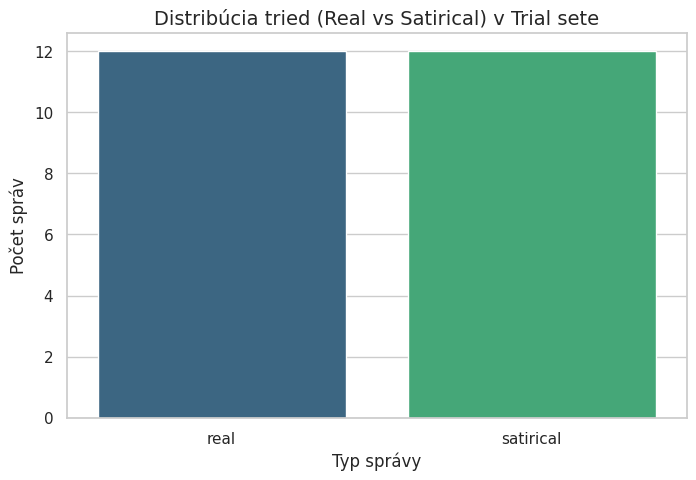

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_trial, x='tag', palette='viridis')
plt.title('Distribúcia tried (Real vs Satirical) v Trial sete', fontsize=14)
plt.xlabel('Typ správy', fontsize=12)
plt.ylabel('Počet správ', fontsize=12)
plt.show()

### 2.2 Dĺžka textu v závislosti od pravdivosti

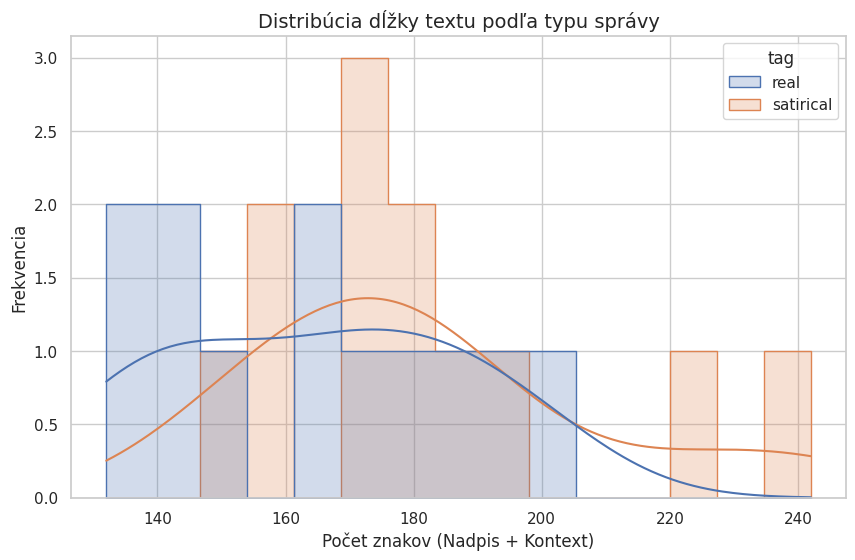

In [ ]:
df_trial['text_length'] = (df_trial['headline'] + " " + df_trial['context']).str.len()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_trial, x='text_length', hue='tag', kde=True, bins=15, element="step")
plt.title('Distribúcia dĺžky textu podľa typu správy', fontsize=14)
plt.xlabel('Počet znakov (Nadpis + Kontext)', fontsize=12)
plt.ylabel('Frekvencia', fontsize=12)
plt.show()

### 2.3 Počet skutočných a satirických na krajiny

Z grafu vidím, že správy sú rovnomerne rozdelené medzi krajiny, a teda každá krajina má 2 real a 2 satirical správy.

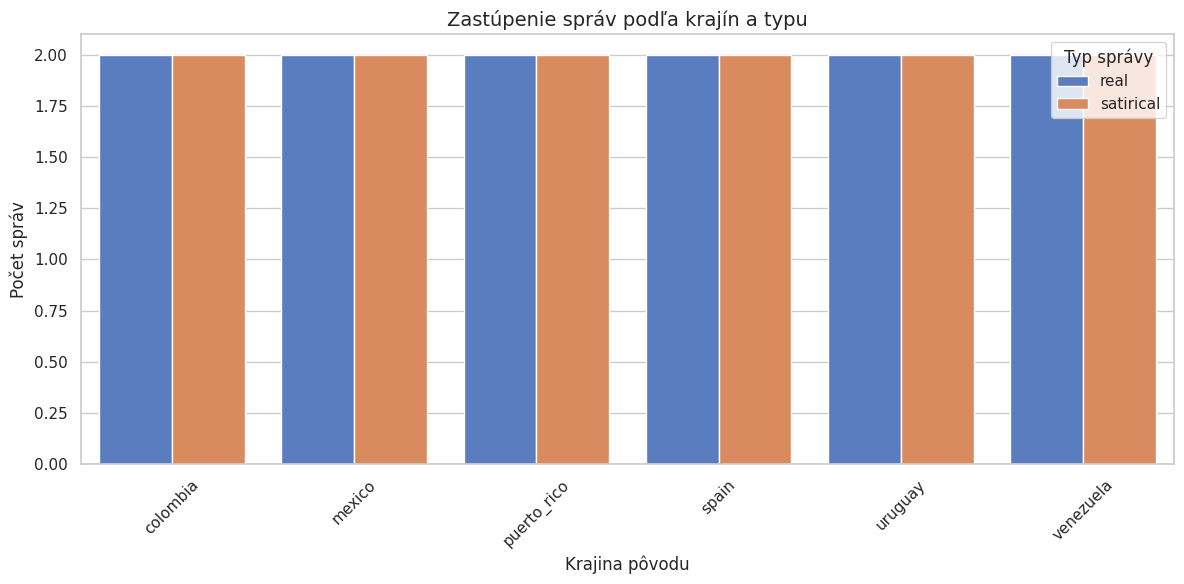

In [ ]:

plt.figure(figsize=(12, 6))
sns.countplot(data=df_trial, x='country', hue='tag', palette='muted')
plt.title('Zastúpenie správ podľa krajín a typu', fontsize=14)
plt.xlabel('Krajina pôvodu', fontsize=12)
plt.ylabel('Počet správ', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Typ správy')
plt.tight_layout()
plt.show()

### 2.4 Dĺžka textu real/satirical podľa krajiny

**Regionálna variabilita dĺžky:**

Graf jasne identifikuje krajiny s vysokým rozptylom dĺžky správ, ako sú Španielsko a Uruguaj. Práve v týchto krajinách vidíme najdlhšie satirické príspevky (presahujúce 220 znakov), zatiaľ čo reálne správy sú výrazne kratšie.

---

**Kategorické zhluky:**

V krajinách ako Mexiko alebo Puerto Rico sa dĺžky oboch typov správ (reálne aj satirické) pohybujú v rozmedzí 140 až 180 znakov. To naznačuje, že v týchto regiónoch nebude samotná dĺžka textu stačiť na úspešnú klasifikáciu a model sa bude musieť spoliehať na hlbšiu sémantiku textu.

---

**Detekcia anomálií:**

Satirické správy (zelená farba) majú v priemere väčší počet znakov ako reálne správy (modrá farba). Reálne správy sú v mnohých krajinách, napríklad v Kolumbii, sústredené v užšom pásme dĺžky, čo môže odrážať novinársky štýl agentúrnych správ.

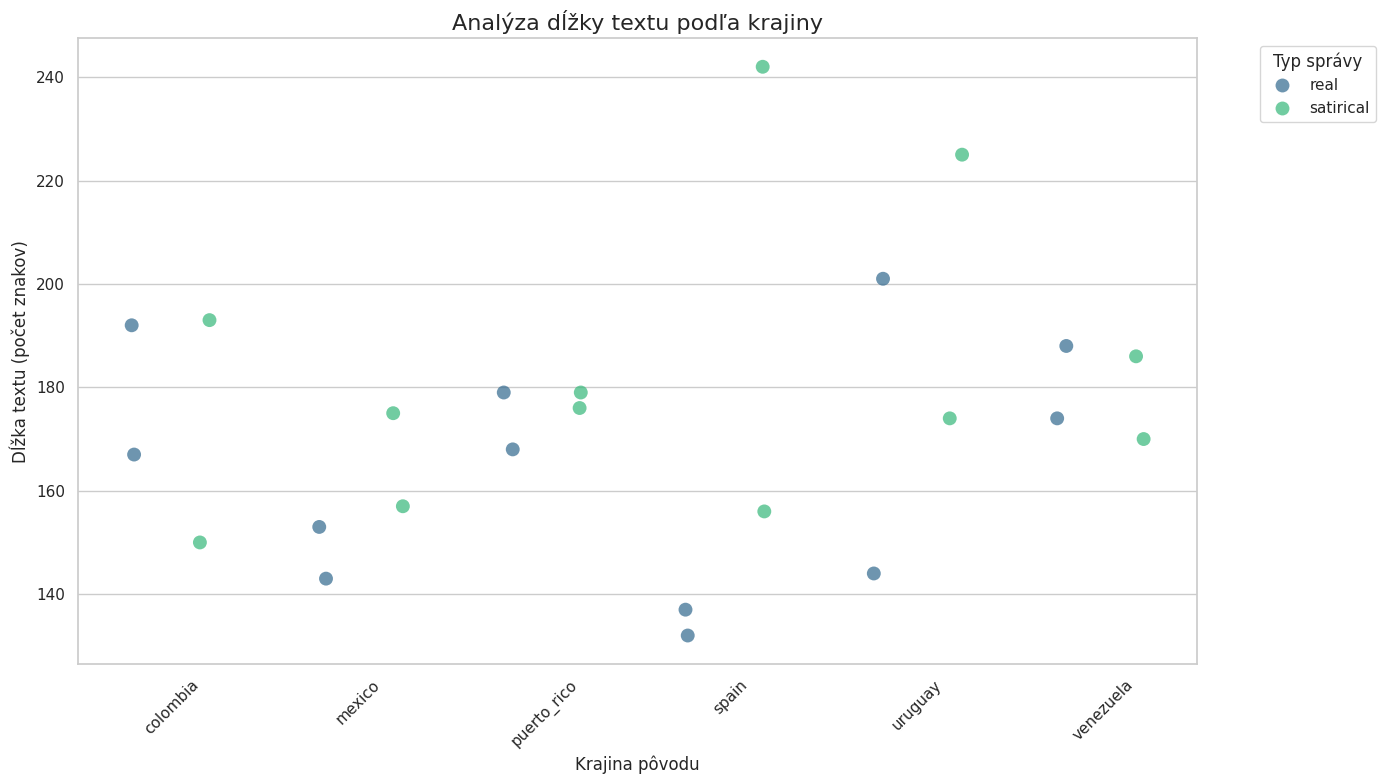

In [ ]:
plt.figure(figsize=(14, 8))

df_trial['text_length'] = (df_trial['headline'] + " " + df_trial['context']).str.len()

plot = sns.stripplot(
    data=df_trial,
    x='country',
    y='text_length',
    hue='tag',
    dodge=True,
    palette='viridis',
    size=10,
    alpha=0.7,
    jitter=True
)

plt.title('Analýza dĺžky textu podľa krajiny', fontsize=16)
plt.xlabel('Krajina pôvodu', fontsize=12)
plt.ylabel('Dĺžka textu (počet znakov)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Typ správy', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 2.5 Analýza dĺžky slov

Graf zobrazuje porovnanie priemernej dĺžky slova pre reálne a satirické správy.

Zistenia z grafu:

**Modrá krivka (reálne správy)** vykazuje veľmi výraznú špičku v úzkom rozmedzí približne 5,0 až 5,5 znakov na slovo. To naznačuje, že reálna žurnalistika v španielčine využíva veľmi konzistentnú a štandardizovanú slovnú zásobu, ktorá je typická pre faktografické spravodajstvo.

---

**Zelená krivka (satirické správy)** je výrazne plochejšia a širšia. To znamená, že satirické texty sú lexikálne oveľa rozmanitejšie – nájdeme v nich správy s veľmi krátkymi, jednoduchými slovami, ale aj texty s nezvyčajne dlhými, komplikovanými výrazmi, ktoré môžu slúžiť na komický alebo ironický efekt.

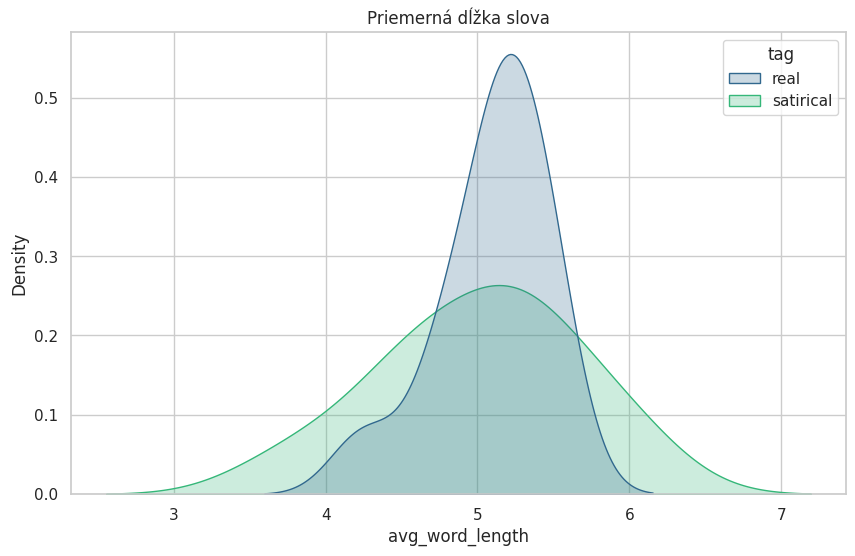

In [ ]:
df_trial['word_count'] = (df_trial['headline'] + " " + df_trial['context']).apply(lambda x: len(str(x).split()))
df_trial['avg_word_length'] = (df_trial['headline'] + " " + df_trial['context']).apply(
    lambda x: sum(len(word) for word in str(x).split()) / len(str(x).split()) if len(str(x).split()) > 0 else 0
)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_trial, x='avg_word_length', hue='tag', fill=True, palette='viridis')
plt.title('Priemerná dĺžka slova')
plt.show()

## 3. Data preprocessing

In [ ]:
import pandas as pd
import re

def preprocess_data(df):
    df = df.copy()

    df['full_text'] = df['headline'] + " " + df['context']

    def clean_text(text):
        text = str(text).replace('\n', ' ').replace('\t', ' ')
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['full_text'] = df['full_text'].apply(clean_text)

    label_map = {'real': 0, 'satirical': 1}
    if 'tag' in df.columns:
        df['label'] = df['tag'].map(label_map)

    return df

df_dev_clean = preprocess_data(df_dev)
df_trial_clean = preprocess_data(df_trial)

## 4. Tokenizácia  

In [ ]:
from transformers import AutoTokenizer

def get_tokenizer(model_name="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"):
    return AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(df, tokenizer, max_length=128):
    tokenized = tokenizer(
        df['full_text'].tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    return tokenized

tokenizer = get_tokenizer()
tokenized_train = tokenize_texts(df_dev_clean, tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [ ]:
label_map = {'real': 0, 'satirical': 1}

df_trial_clean['label'] = df_trial_clean['tag'].map(label_map)

from datasets import Dataset
train_ds = Dataset.from_pandas(df_trial_clean[['full_text', 'label']])

def tokenize_function(examples):
    return tokenizer(
        examples["full_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = train_ds.map(tokenize_function, batched=True, remove_columns=["full_text"])
tokenized_dataset.set_format("torch")

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

## 5.1. Klasifikácia cez zero-shot

In [ ]:
from transformers import pipeline
from tqdm.auto import tqdm
import numpy as np

def run_zero_shot_inference(df, model_name, batch_size=2):

    classifier = pipeline(
        "zero-shot-classification",
        model=model_name,
        device=0
    )

    label_sets = [
        ["real news", "satirical news"],
        ["real news article", "fake or parody news"],
        ["true information", "humorous or absurd story"],

    ]

    hypothesis = "This is {}."

    texts = df['headline'].fillna("").tolist()

    all_results = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        batch_scores = np.zeros((len(batch), 2))

        for labels in label_sets:
            outputs = classifier(
                batch,
                labels,
                hypothesis_template=hypothesis,
                multi_label=False
            )

            for j, out in enumerate(outputs):
                score_dict = dict(zip(out["labels"], out["scores"]))

                batch_scores[j][0] += score_dict[labels[0]]
                batch_scores[j][1] += score_dict[labels[1]]

        batch_scores /= len(label_sets)

        all_results.extend(batch_scores)

    preds = []
    confs = []

    for s in all_results:
        idx = np.argmax(s)
        preds.append(["real", "satirical"][idx])
        confs.append(s[idx])

    df['prediction'] = preds
    df['confidence_score'] = confs

    return df

In [ ]:
def get_scores(df, model_name, batch_size=4):
    classifier = pipeline("zero-shot-classification", model=model_name, device=0)

    df['full_text'] = df['headline'].fillna("") + " " + df['context'].fillna("")
    texts = df['full_text'].tolist()

    label_sets = [
        ["real news", "satirical news"],
        ["factual report", "parody story"]
    ]

    hypothesis = "This text is {}."
    all_scores = []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]
        batch_satirical_scores = np.zeros(len(batch))

        for labels in label_sets:
            outputs = classifier(batch, labels, hypothesis_template=hypothesis, multi_label=False)
            for j, out in enumerate(outputs):
                score_dict = dict(zip(out["labels"], out["scores"]))
                batch_satirical_scores[j] += score_dict[labels[1]]

        batch_satirical_scores /= len(label_sets)
        all_scores.extend(batch_satirical_scores)

    return np.array(all_scores)

trial_sat_scores = get_scores(df_trial, "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/6 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
#72%
import numpy as np
import pandas as pd
from transformers import pipeline
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
import warnings

warnings.filterwarnings('ignore')

def run_ensemble_pipeline(df_trial, df_dev, model_names, threshold=None, calibrate=True):
    label_sets = [
        ["real news", "satirical news"],
        ["factual report", "parody story"],
    ]
    hypothesis = "This text is {}."

    def prepare_texts(df):
        texts = []
        for _, row in df.iterrows():
            headline = str(row['headline']).strip() if pd.notna(row['headline']) else ""
            context = str(row['context']).strip() if pd.notna(row['context']) else ""
            texts.append(f"{headline} {context}" if context else headline)
        return texts

    trial_texts = prepare_texts(df_trial)
    dev_texts = prepare_texts(df_dev)

    print(f"Načítavam {len(model_names)} modelov pre ensemble...")
    classifiers = []
    for model_name in model_names:
        try:
            clf = pipeline("zero-shot-classification",
                          model=model_name,
                          device=0,
                          multi_label=False)
            classifiers.append(clf)
            print(f"OK {model_name}")
        except Exception as e:
            print(f"ERROR Chyba pri {model_name}: {e}")

    def get_model_scores(texts, classifier):
        scores = []
        model_name_short = classifier.model.config._name_or_path.split('/')[-1][:20]
        for text in tqdm(texts, desc=f"Inferencia: {model_name_short}", leave=False):
            score_sum = 0
            for labels in label_sets:
                out = classifier(text, labels, hypothesis_template=hypothesis)
                score_dict = dict(zip(out["labels"], out["scores"]))
                score_sum += score_dict[labels[1]]
            scores.append(score_sum / len(label_sets))
        return np.array(scores)

    print("\n" + "="*50)
    print("FÁZA 1: Výpočet a optimalizácia na TRIALE")
    print("="*50)

    trial_individual_scores = []
    for clf in classifiers:
        trial_individual_scores.append(get_model_scores(trial_texts, clf))

    y_true_binary = (df_trial['tag'].values == 'satirical').astype(int)

    print("Vypočítavam váhy modelov...")
    model_weights = []
    for scores in trial_individual_scores:
        best_m_f1 = 0
        for t in np.arange(0.2, 0.8, 0.05):
            m_f1 = f1_score(y_true_binary, (scores > t).astype(int), average='macro')
            if m_f1 > best_m_f1:
                best_m_f1 = m_f1
        model_weights.append(best_m_f1)

    model_weights = np.array(model_weights) / sum(model_weights)
    for i, name in enumerate(model_names):
        print(f"  Model: {name.split('/')[-1]} -> Váha: {model_weights[i-1]:.4f}")

    trial_ensemble_scores = np.average(trial_individual_scores, axis=0, weights=model_weights)

    if calibrate:
        print("Kalibrujem pravdepodobnosti (Logistic Regression)...")
        cal_model = LogisticRegression(C=1.0, random_state=42)
        cal_model.fit(trial_ensemble_scores.reshape(-1, 1), y_true_binary)
        trial_final_scores = cal_model.predict_proba(trial_ensemble_scores.reshape(-1, 1))[:, 1]
    else:
        trial_final_scores = trial_ensemble_scores

    if threshold is None:
        print("Optimalizujem threshold pre F1-Macro...")
        best_threshold = 0.5
        max_f1 = 0
        for t in np.arange(0.1, 0.9, 0.01):
            y_pred = (trial_final_scores > t).astype(int)
            current_f1 = f1_score(y_true_binary, y_pred, average='macro')
            if current_f1 > max_f1:
                max_f1 = current_f1
                best_threshold = t
        threshold = best_threshold

    y_pred_trial = ["satirical" if s > threshold else "real" for s in trial_final_scores]
    print(f"\nNajlepší threshold: {threshold:.3f} (F1-Macro: {max_f1:.4f})")
    print("\nREPORT NA TRIALE:")
    print(classification_report(df_trial['tag'], y_pred_trial))

    print("\n" + "="*50)
    print("FÁZA 2: Inferencia na DEV sete")
    print("="*50)

    dev_individual_scores = []
    for clf in classifiers:
        dev_individual_scores.append(get_model_scores(dev_texts, clf))

    dev_ensemble_scores = np.average(dev_individual_scores, axis=0, weights=model_weights)

    if calibrate:
        dev_final_scores = cal_model.predict_proba(dev_ensemble_scores.reshape(-1, 1))[:, 1]
    else:
        dev_final_scores = dev_ensemble_scores

    df_dev['tag'] = ["satirical" if s > threshold else "real" for s in dev_final_scores]
    df_dev[['id', 'tag']].to_csv('task1.tsv', sep='\t', index=False)

    print(f"\nSúbor 'task1.tsv' úspešne vytvorený!")
    print(df_dev['tag'].value_counts())

    return results

model_names = [
    "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    "facebook/bart-large-mnli",
    "joeddav/xlm-roberta-large-xnli",
    "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
]

results = run_ensemble_pipeline(df_trial, df_dev, model_names)

Načítavam 5 modelov pre ensemble...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ MoritzLaurer/mDeBERTa-v3-base-mnli-xnli


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

Inferencia: DeBERTa-v3-base-mnli:   0%|          | 0/540 [00:00<?, ?it/s]

Inferencia: bart-large-mnli:   0%|          | 0/540 [00:00<?, ?it/s]

Inferencia: xlm-roberta-large-xn:   0%|          | 0/540 [00:00<?, ?it/s]

Inferencia: DeBERTa-v3-large-mnl:   0%|          | 0/540 [00:00<?, ?it/s]


Súbor 'task1.tsv' úspešne vytvorený!
tag
satirical    325
real         215
Name: count, dtype: int64


In [ ]:
#73%
import numpy as np
import pandas as pd
from transformers import pipeline
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import MinMaxScaler
import warnings

warnings.filterwarnings('ignore')

def run_stable_ensemble(df_trial, df_dev, model_names):
    label_sets = [
        ["genuine news report", "satirical news parody"],
        ["factual article", "humorous satirical fiction"],
        ["serious journalism", "ironic satire"]
    ]
    hypothesis = "This text is {}."

    def prepare_texts(df):
        texts = []
        for _, row in df.iterrows():
            h = str(row['headline']).strip() if pd.notna(row['headline']) else ""
            c = str(row['context']).strip() if pd.notna(row['context']) else ""
            texts.append(f"Headline: {h} | Content: {c}" if c else h)
        return texts

    trial_texts = prepare_texts(df_trial)
    dev_texts = prepare_texts(df_dev)
    y_true_binary = (df_trial['tag'].values == 'satirical').astype(int)

    def get_scores(texts, model_name):
        clf = pipeline("zero-shot-classification", model=model_name, device=0, multi_label=False)
        all_scores = []
        for text in tqdm(texts, desc=f"Model: {model_name.split('/')[-1]}", leave=False):
            s_sum = 0
            for labels in label_sets:
                out = clf(text, labels, hypothesis_template=hypothesis)
                s_sum += dict(zip(out["labels"], out["scores"]))[labels[1]]
            all_scores.append(s_sum / len(label_sets))
        return np.array(all_scores)

    trial_raw = [get_scores(trial_texts, m) for m in model_names]
    dev_raw = [get_scores(dev_texts, m) for m in model_names]

    trial_norm = []
    dev_norm = []
    scaler = MinMaxScaler()

    for t_s, d_s in zip(trial_raw, dev_raw):
        t_s_norm = scaler.fit_transform(t_s.reshape(-1, 1)).flatten()
        d_s_norm = scaler.transform(d_s.reshape(-1, 1)).flatten()
        trial_norm.append(t_s_norm)
        dev_norm.append(d_s_norm)

    weights = []
    for scores in trial_norm:
        best_f1 = 0
        for t in np.arange(0.3, 0.7, 0.05):
            f = f1_score(y_true_binary, (scores > t).astype(int), average='macro')
            if f > best_f1: best_f1 = f
        weights.append(best_f1**2)

    weights = np.array(weights) / sum(weights)

    trial_final = np.average(trial_norm, axis=0, weights=weights)
    dev_final = np.average(dev_norm, axis=0, weights=weights)

    best_t = 0.5
    best_f1 = 0
    for t in np.arange(0.3, 0.7, 0.01):
        f = f1_score(y_true_binary, (trial_final > t).astype(int), average='macro')
        if f > best_f1:
            best_f1 = f
            best_t = t

    y_pred_trial = ["satirical" if s > best_t else "real" for s in trial_final]
    df_dev['tag'] = ["satirical" if s > best_t else "real" for s in dev_final]

    print(f"\nOptimalizovaný threshold: {best_t:.2f}")
    print(classification_report(df_trial['tag'], y_pred_trial))

    df_dev[['id', 'tag']].to_csv('task1.tsv', sep='\t', index=False)
    return df_dev

model_names = [
    "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    "facebook/bart-large-mnli",
    "joeddav/xlm-roberta-large-xnli",
    "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
]
results = run_stable_ensemble(df_trial, df_dev, model_names)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: mDeBERTa-v3-base-mnli-xnli:   0%|          | 0/24 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Model: xlm-roberta-large-xnli:   0%|          | 0/540 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: DeBERTa-v3-large-mnli-fever-anli-ling-wanli:   0%|          | 0/540 [00:00<?, ?it/s]


Optimalizovaný threshold: 0.45
              precision    recall  f1-score   support

        real       0.83      0.83      0.83        12
   satirical       0.83      0.83      0.83        12

    accuracy                           0.83        24
   macro avg       0.83      0.83      0.83        24
weighted avg       0.83      0.83      0.83        24



## 5.2. Klasifikacia cez fine-tuning

In [ ]:
import numpy as np
import pandas as pd
import torch
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import MinMaxScaler
from datasets import Dataset
import warnings

warnings.filterwarnings('ignore')


def get_ensemble_scores(df_trial, df_dev, model_names):
    label_sets = [
        ["genuine news report", "satirical news parody"],
        ["factual article", "humorous satirical fiction"],
        ["serious journalism", "ironic satire"]
    ]
    hypothesis = "This text is {}."

    def prepare_texts(df):
        texts = []
        for _, row in df.iterrows():
            h = str(row['headline']).strip() if pd.notna(row['headline']) else ""
            c = str(row['context']).strip() if pd.notna(row['context']) else ""
            texts.append(f"Headline: {h} | Content: {c}" if c else h)
        return texts

    trial_texts = prepare_texts(df_trial)
    dev_texts = prepare_texts(df_dev)
    y_true_binary = (df_trial['tag'].values == 'satirical').astype(int)

    def get_scores(texts, model_name):
        clf = pipeline("zero-shot-classification", model=model_name, device=0 if torch.cuda.is_available() else -1, multi_label=False)
        all_scores = []
        for text in tqdm(texts, desc=f"Model: {model_name.split('/')[-1]}", leave=False):
            s_sum = 0
            for labels in label_sets:
                out = clf(text, labels, hypothesis_template=hypothesis)
                s_sum += dict(zip(out["labels"], out["scores"]))[labels[1]]
            all_scores.append(s_sum / len(label_sets))
        return np.array(all_scores)

    trial_raw = [get_scores(trial_texts, m) for m in model_names]
    dev_raw = [get_scores(dev_texts, m) for m in model_names]

    trial_norm = []
    dev_norm = []
    scaler = MinMaxScaler()

    for t_s, d_s in zip(trial_raw, dev_raw):
        t_s_norm = scaler.fit_transform(t_s.reshape(-1, 1)).flatten()
        d_s_norm = scaler.transform(d_s.reshape(-1, 1)).flatten()
        trial_norm.append(t_s_norm)
        dev_norm.append(d_s_norm)

    weights = []
    for scores in trial_norm:
        best_f1 = 0
        for t in np.arange(0.3, 0.7, 0.05):
            f = f1_score(y_true_binary, (scores > t).astype(int), average='macro')
            if f > best_f1: best_f1 = f
        weights.append(best_f1**2)

    weights = np.array(weights) / sum(weights)

    trial_final = np.average(trial_norm, axis=0, weights=weights)
    dev_final = np.average(dev_norm, axis=0, weights=weights)

    best_t = 0.5
    best_f1_val = 0
    for t in np.arange(0.3, 0.7, 0.01):
        f = f1_score(y_true_binary, (trial_final > t).astype(int), average='macro')
        if f > best_f1_val:
            best_f1_val = f
            best_t = t

    print(f"\nZero-shot Optimalizovaný threshold: {best_t:.2f} (F1: {best_f1_val:.4f})")
    return trial_final, dev_final, best_t


def prepare_hf_dataset(df, tokenizer):
    label_map = {'real': 0, 'satirical': 1}
    def tokenize_func(examples):
        texts = [f"Headline: {h} [SEP] Content: {c}" if pd.notna(c) else str(h)
                 for h, c in zip(examples['headline'], examples['context'])]
        return tokenizer(texts, padding="max_length", truncation=True, max_length=256)

    ds = Dataset.from_pandas(df)
    if 'tag' in df.columns:
        ds = ds.map(lambda x: {'labels': label_map[x['tag']]}, batched=False)
    ds = ds.map(tokenize_func, batched=True)
    return ds

model_names = [
    "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    "facebook/bart-large-mnli",
    "joeddav/xlm-roberta-large-xnli",
    "MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli"
]

trial_scores, dev_scores, best_t = get_ensemble_scores(df_trial, df_dev, model_names)

margin = 0.15
pseudo_mask = (dev_scores > (best_t + margin)) | (dev_scores < (best_t - margin))
df_pseudo = df_dev[pseudo_mask].copy()
df_pseudo['tag'] = ["satirical" if s > best_t else "real" for s in dev_scores[pseudo_mask]]

print(f"Vytvorených {len(df_pseudo)} pseudo-labelov z {len(df_dev)} dev vzoriek.")

df_train_combined = pd.concat([df_trial, df_pseudo], axis=0).reset_index(drop=True)

FT_MODEL_NAME = "microsoft/mdeberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(FT_MODEL_NAME, num_labels=2)

train_dataset = prepare_hf_dataset(df_train_combined, tokenizer)
val_dataset = prepare_hf_dataset(df_trial, tokenizer)

training_args = TrainingArguments(
    output_dir="./ft_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=lambda p: {"f1": f1_score(p.label_ids, np.argmax(p.predictions, axis=-1), average='macro')}
)

print("\nŠtartujem Fine-tuning na kombinovaných dátach...")
trainer.train()

print("\nGenerujem finálne predikcie...")
dev_dataset = prepare_hf_dataset(df_dev, tokenizer)
raw_preds = trainer.predict(dev_dataset)
final_tags = np.argmax(raw_preds.predictions, axis=-1)

df_dev['tag'] = ["satirical" if p == 1 else "real" for p in final_tags]
df_dev[['id', 'tag']].to_csv('task1.tsv', sep='\t', index=False)

print("Hotovo! Výsledky sú v task1.tsv")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: mDeBERTa-v3-base-mnli-xnli:   0%|          | 0/24 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Generujem finálne predikcie...


Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Hotovo! Výsledky sú v task1.tsv
